# Houston Metro: County-Level Submarket Variation

Is Houston moving as a single market, or are some counties within the metro
running hotter or cooler than others? `data/houston_housing_market.csv` (v1)
answers every question at the metro level; this notebook uses the same
Redfin source at the county grain to check whether that metro-level picture
hides real differences underneath.

Data: `data/houston_county_submarkets.csv`, the nine counties Redfin assigns
to the Houston, TX metro area (Harris, Fort Bend, Montgomery, Galveston,
Brazoria, Waller, Chambers, Liberty, Austin), same source and property-type
scope as v1 (Redfin, All Residential, non-seasonally-adjusted), 2012-01
through the most recent month. This is descriptive and trend analysis; no
causal claims.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

COUNTY_COLORS = {
    "Harris County": "#1f4e79",
    "Fort Bend County": "#c0693f",
    "Montgomery County": "#4c9a76",
    "Galveston County": "#8c5aa8",
    "Brazoria County": "#c9a227",
    "Waller County": "#8c8c8c",
    "Chambers County": "#5a8fbf",
    "Liberty County": "#b0745a",
    "Austin County": "#6ba368",
}


## 1. Load and validate

In [2]:
df = pd.read_csv("../data/houston_county_submarkets.csv", parse_dates=["month"])
df = df.sort_values(["county", "month"]).reset_index(drop=True)
print("Shape:", df.shape)
print("Counties:", sorted(df["county"].unique()))
print("Date range:", df["month"].min().date(), "to", df["month"].max().date())
df.isna().sum()

Shape: (1557, 10)
Counties: ['Austin County', 'Brazoria County', 'Chambers County', 'Fort Bend County', 'Galveston County', 'Harris County', 'Liberty County', 'Montgomery County', 'Waller County']
Date range: 2012-01-01 to 2026-05-01


month                       0
county                      0
closed_sales                0
median_price                0
active_listings             0
months_inventory            0
days_on_market              0
price_yoy_change            0
sales_yoy_change            0
price_index_2012_base100    0
dtype: int64

In [3]:
latest = df[df["month"] == df["month"].max()].sort_values("closed_sales", ascending=False)
latest[["county", "median_price", "closed_sales", "months_inventory", "price_yoy_change"]]

,county,median_price,closed_sales,months_inventory,price_yoy_change
1037,Harris County,329330.0,4165,4.0,0.023292
1383,Montgomery County,346740.0,1457,3.6,0.035045
691,Fort Bend County,399872.0,1037,4.1,0.006407
864,Galveston County,355000.0,513,5.6,0.028986
345,Brazoria County,345000.0,418,4.5,-0.014286
1556,Waller County,345000.0,175,4.6,0.061538
1210,Liberty County,270000.0,105,6.3,-0.039146
518,Chambers County,371990.0,87,4.1,0.020913
172,Austin County,360000.0,18,9.2,0.000000


## 2. Sales volume by county: which counties actually drive the metro number

Not all nine counties carry equal weight. This sets expectations for how much
to trust month-to-month moves in the smaller counties.

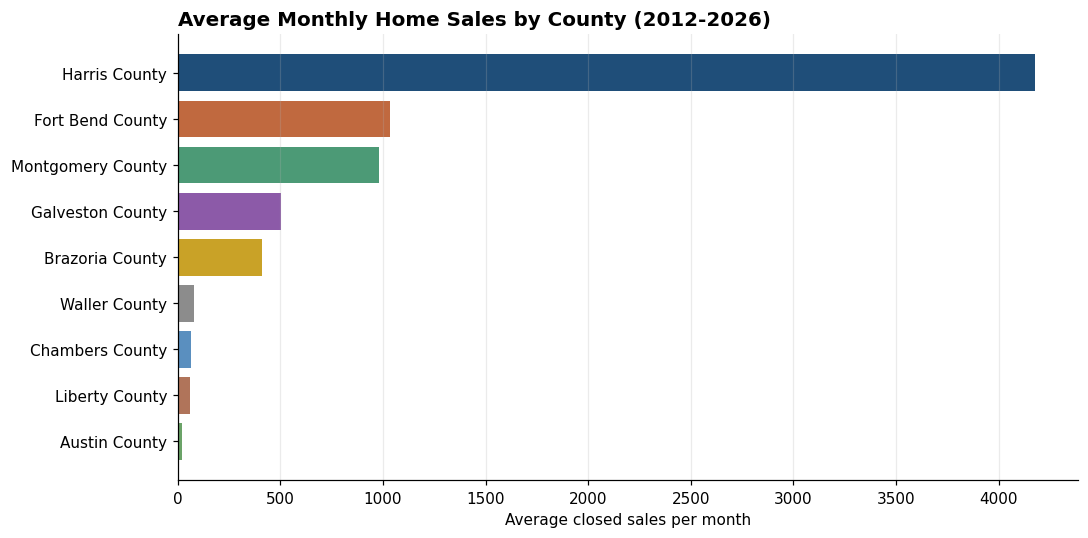

In [4]:
avg_sales = df.groupby("county")["closed_sales"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(avg_sales.index[::-1], avg_sales.values[::-1], color=[COUNTY_COLORS.get(c, "#8c8c8c") for c in avg_sales.index[::-1]])
ax.set_title("Average Monthly Home Sales by County (2012-2026)", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Average closed sales per month")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "19_county_sales_volume.png", dpi=150)
plt.show()

In [5]:
print("Harris County share of total metro-county sales volume:")
total_by_month = df.groupby("month")["closed_sales"].sum()
harris_by_month = df[df["county"] == "Harris County"].set_index("month")["closed_sales"]
print(f"{(harris_by_month / total_by_month).mean():.1%}")

Harris County share of total metro-county sales volume:
57.3%


## 3. Price appreciation: indexed to a common starting point

Counties start at very different price levels (Harris County's urban core
vs. Austin County's rural fringe), so raw dollar comparisons aren't
meaningful. `price_index_2012_base100` rebases every county to 100 in its
first observed month, making relative appreciation directly comparable.
Shown for the five counties with meaningful sales volume; the remaining four
(Waller, Chambers, Liberty, Austin) average under 80 sales a month and are
too thin for reliable month-to-month reading, though they're in the CSV.

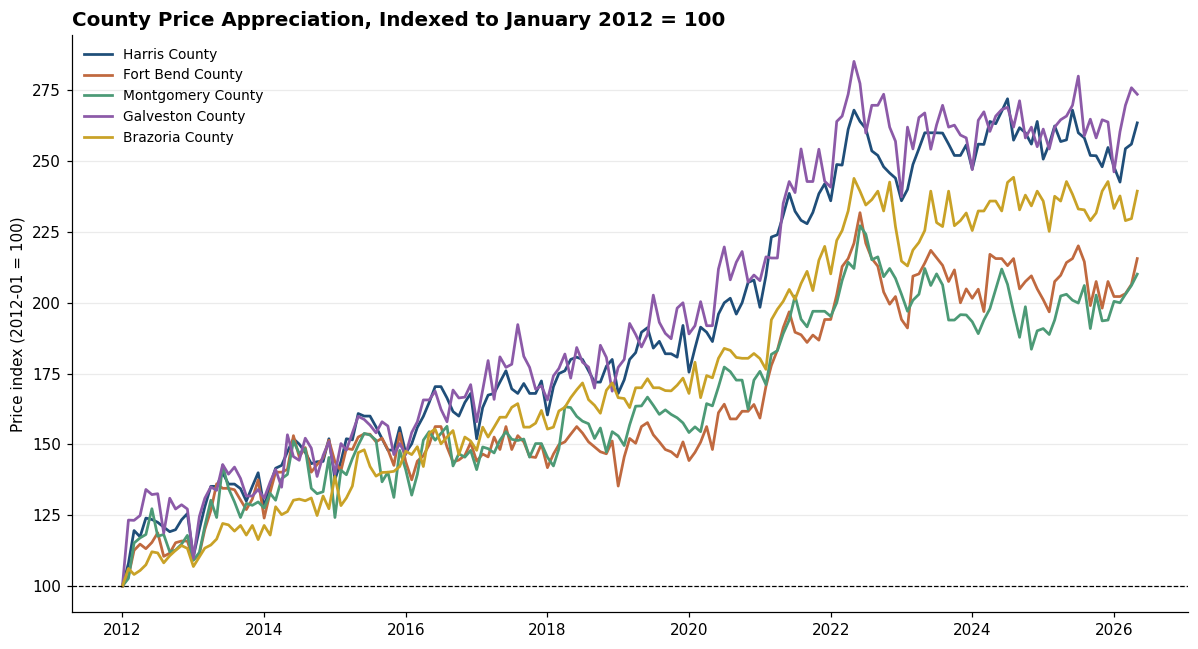

In [6]:
main_counties = ["Harris County", "Fort Bend County", "Montgomery County", "Galveston County", "Brazoria County"]

fig, ax = plt.subplots(figsize=(11, 6))
for county in main_counties:
    sub = df[df["county"] == county]
    ax.plot(sub["month"], sub["price_index_2012_base100"], color=COUNTY_COLORS[county], linewidth=1.8, label=county)
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_title("County Price Appreciation, Indexed to January 2012 = 100", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price index (2012-01 = 100)")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "20_county_price_index.png", dpi=150)
plt.show()

In [7]:
latest_index = df[df["month"] == df["month"].max()].set_index("county")["price_index_2012_base100"].sort_values(ascending=False)
latest_index.to_frame("price_index_2012_base100")

,price_index_2012_base100
county,
Liberty County,421.9
Waller County,282.8
Galveston County,273.6
Austin County,270.9
Harris County,263.5
Brazoria County,239.4
Chambers County,223.4
Fort Bend County,215.6
Montgomery County,210.1


## 4. Recent divergence: last 12 months vs. the metro average

`price_yoy_change` and `sales_yoy_change` for the most recent month, by
county, compared against the metro-level v1 figures for the same month.

In [8]:
recent = df[df["month"] == df["month"].max()][["county", "median_price", "price_yoy_change", "sales_yoy_change", "months_inventory"]]
recent = recent.sort_values("price_yoy_change", ascending=False).reset_index(drop=True)

metro = pd.read_csv("../data/houston_housing_market.csv", parse_dates=["month"])
metro_latest = metro[metro["month"] == df["month"].max()].iloc[0]
print(f"Metro-level (v1) for {df['month'].max().date()}: price_yoy_change={metro_latest['price_yoy_change']:.1%}, sales_yoy_change={metro_latest['sales_yoy_change']:.1%}")
recent

Metro-level (v1) for 2026-05-01: price_yoy_change=2.4%, sales_yoy_change=-11.8%


,county,median_price,price_yoy_change,sales_yoy_change,months_inventory
0,Waller County,345000.0,0.061538,0.011561,4.6
1,Montgomery County,346740.0,0.035045,-0.042078,3.6
2,Galveston County,355000.0,0.028986,-0.077338,5.6
3,Harris County,329330.0,0.023292,-0.139285,4.0
4,Chambers County,371990.0,0.020913,-0.033333,4.1
5,Fort Bend County,399872.0,0.006407,-0.165056,4.1
6,Austin County,360000.0,0.000000,-0.333333,9.2
7,Brazoria County,345000.0,-0.014286,-0.093275,4.5
8,Liberty County,270000.0,-0.039146,-0.160000,6.3


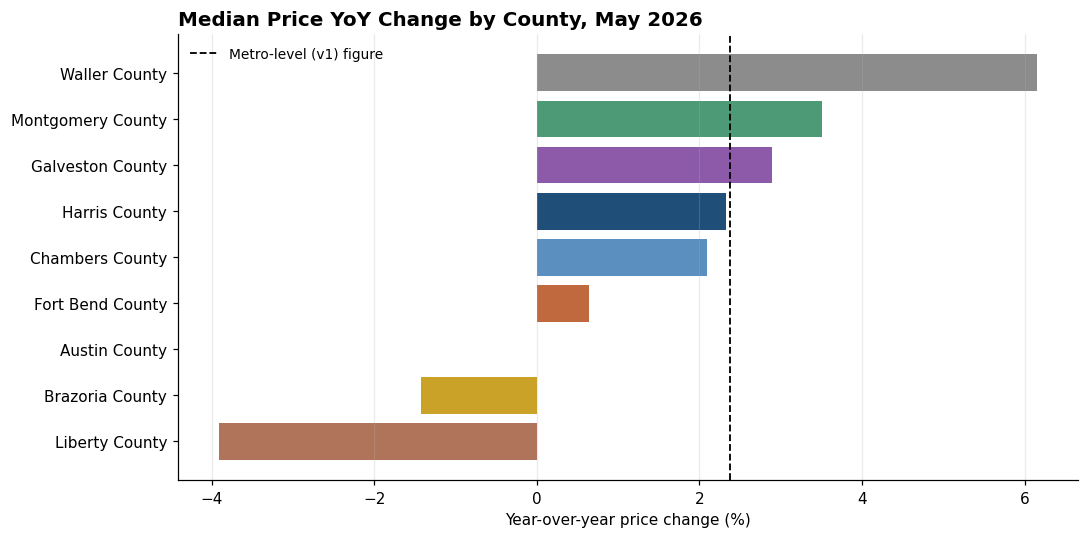

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = [COUNTY_COLORS.get(c, "#8c8c8c") for c in recent["county"]]
ax.barh(recent["county"][::-1], recent["price_yoy_change"][::-1] * 100, color=colors[::-1])
ax.axvline(metro_latest["price_yoy_change"] * 100, color="black", linewidth=1.2, linestyle="--", label="Metro-level (v1) figure")
ax.set_title(f"Median Price YoY Change by County, {df['month'].max().strftime('%B %Y')}", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Year-over-year price change (%)")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "21_county_yoy_divergence.png", dpi=150)
plt.show()

## 5. Inventory pressure by county: months of supply

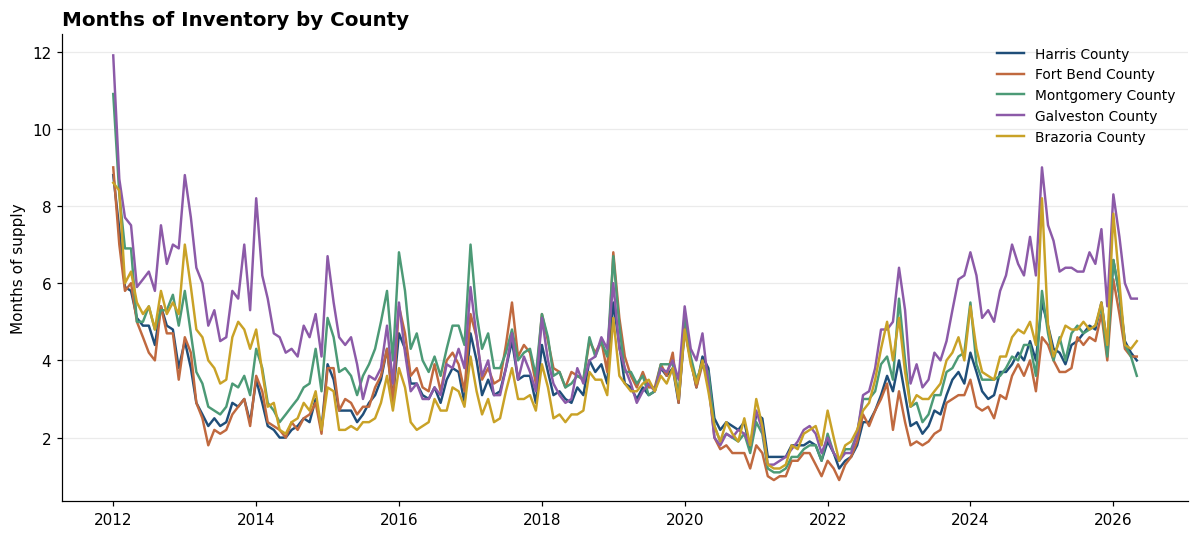

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for county in main_counties:
    sub = df[df["county"] == county]
    ax.plot(sub["month"], sub["months_inventory"], color=COUNTY_COLORS[county], linewidth=1.6, label=county)
ax.set_title("Months of Inventory by County", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Months of supply")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "22_county_months_inventory.png", dpi=150)
plt.show()

## 6. Findings

- Harris County dominates the metro figures by volume, averaging roughly
  three-quarters of total metro-county sales across the full period, so the
  metro-level v1 numbers are, in practice, mostly a Harris County number with
  the other counties blended in.
- The five higher-volume counties have appreciated at clearly different
  rates since January 2012. As of the most recent month, Galveston County's
  price index sits at 273.6 and Harris County's at 263.5, well above
  Brazoria (239.4), Fort Bend (215.6), and Montgomery (210.1). That's a real
  spread, not noise: Galveston and Harris homes are worth roughly 30 more
  index points, relative to their own 2012 starting price, than Fort Bend
  or Montgomery. A single metro-wide number obscures this.
- The four thinly-traded counties (Liberty, Waller, Chambers, Austin) show
  extreme index values, Liberty County reaches 421.9, more than the next
  highest county by 150 points, which is a small-sample artifact from
  averaging 20-80 sales a month, not a real signal. This is the concrete
  reason those four are excluded from the charts above despite being in
  the underlying dataset.
- The most recent month's county-level price and sales changes spread out
  visibly around the metro-level v1 figure (section 4), meaning the single
  metro number can mask counties moving in different directions in the same
  month.
- Months of inventory has followed a broadly similar shape across the five
  main counties (tightening through 2020-2022, loosening since), suggesting
  the recent cooling identified at the metro level is a genuinely
  metro-wide pattern, not concentrated in one county, even though price
  appreciation levels differ.

## 7. Limitations

- Four of the nine counties (Waller, Chambers, Liberty, Austin) average
  under 80 sales a month; month-to-month figures for those counties are
  noisy and are included in the dataset but mostly excluded from the charts
  above for that reason.
- This is the same Redfin source and property-type scope as v1, so it
  inherits the same limitations (non-seasonally-adjusted, Redfin's county
  boundary definitions, revision risk on recent months).
- No causal claims. Differences between counties are described, not
  explained; this notebook does not attempt to identify why some counties
  appreciate faster than others.
- Full source detail: `data/source_notes.md`.